In [1]:
import pandas as pd
from data_preparation import Data_Preparation as dp

prep = dp()
df = prep.prepare_data_general()
X = df.drop(columns=['PumpTimeInSeconds','WaterLevel'])
y = df['PumpTimeInSeconds']
X

,Temperature,AirHumidity,SoilHumidity,LightIntensity,seconds_since_watering,OptimalTemperature,OptimalAirHumidity,OptimalSoilHumidity,OptimalLightIntensity
0,20.19,52.35,57.88,1422.88,0.0,20.7,50.8,57.5,1282.9
1,18.78,52.77,58.26,1373.85,0.0,20.1,50.4,58.0,1282.1
2,18.38,68.59,72.08,1251.32,0.0,19.1,68.9,71.5,955.6
3,20.63,73.84,66.85,883.62,0.0,21.6,70.9,66.7,782.0
4,21.71,61.93,57.97,1248.57,0.0,22.1,59.3,57.5,793.8
...,...,...,...,...,...,...,...,...,...
149995,17.55,67.87,70.74,4.00,35996400.0,20.0,70.3,71.1,1047.1
149996,18.11,54.31,45.52,9.74,255600.0,20.1,50.4,58.0,1282.1
149997,18.98,52.22,45.00,3.85,151200.0,20.7,50.8,57.5,1282.9
149998,20.54,48.36,35.24,0.00,3600.0,22.3,50.2,50.6,722.5


In [2]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV

# Assuming X is your feature matrix and y is your target variable
# First split into training and temp (validation + test)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
X_train,X_val,y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.20, random_state=42)
X_train

,Temperature,AirHumidity,SoilHumidity,LightIntensity,seconds_since_watering,OptimalTemperature,OptimalAirHumidity,OptimalSoilHumidity,OptimalLightIntensity
145775,20.69,61.68,47.06,1008.73,540000.0,22.1,59.3,57.5,793.8
61312,21.62,66.60,60.59,549.38,14713200.0,21.6,70.9,66.7,782.0
128370,18.04,56.17,51.22,0.00,30808800.0,20.6,55.2,62.4,1980.7
48242,24.85,53.06,36.40,1006.90,104400.0,22.3,50.2,50.6,722.5
54025,24.40,57.68,38.42,2558.73,504000.0,21.3,59.0,51.6,2115.8
...,...,...,...,...,...,...,...,...,...
49713,23.63,49.16,51.67,2132.38,11930400.0,20.6,55.2,62.4,1980.7
87939,20.99,54.22,47.20,1062.40,435600.0,20.1,50.4,58.0,1282.1
138288,21.74,68.91,63.04,901.60,33188400.0,22.5,71.0,68.0,748.2
78493,26.32,63.55,56.24,785.90,18835200.0,22.4,69.9,66.9,729.9


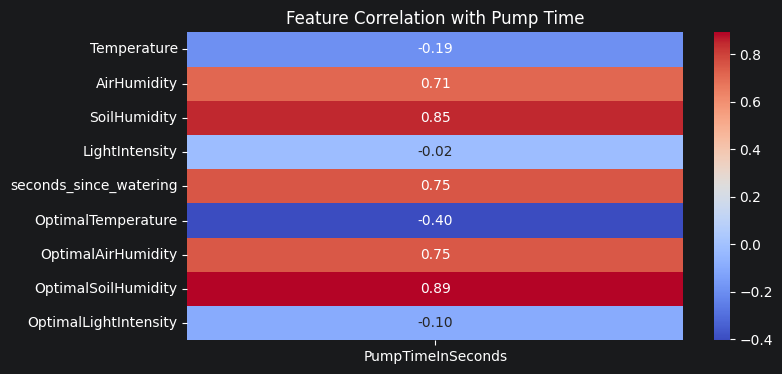

In [3]:
from sklearn.metrics import confusion_matrix, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt

# correlation of each feature with target
corr_series = X_train.corrwith(y_train)

plt.figure(figsize=(8, 4))
sns.heatmap(corr_series.to_frame(name='PumpTimeInSeconds'),
            annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation with Pump Time')
plt.show()

In [4]:
from sklearn.preprocessing import StandardScaler
# X_train = X_train.drop(columns=['OptimalSoilHumidity','OptimalAirHumidity','SoilHumidity','AirHumidity'])
# X_val = X_val.drop(columns=['OptimalSoilHumidity','OptimalAirHumidity','SoilHumidity','AirHumidity'])
# X_test = X_test.drop(columns=['OptimalSoilHumidity','OptimalAirHumidity','SoilHumidity','AirHumidity'])
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_val = scaler.transform(X_val)
# X_test = scaler.transform(X_test)

In [8]:
import xgboost as xgb
import numpy as np
import random
from sklearn.metrics import mean_absolute_error

# convert to GPU DMatrix
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)

param_grid = {
    "max_depth": [3, 6, 9, 12, 15],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "min_child_weight": [1, 3, 5],
    "reg_alpha": [0, 0.01, 0.1, 1, 10],
    "reg_lambda": [0.1, 1, 10, 100],
}

def sample_params():
    return {
        "objective": "reg:squarederror",
        "eval_metric": "mae",
        "tree_method": "hist",
        "device": "cuda",
        "max_depth": random.choice(param_grid["max_depth"]),
        "learning_rate": random.choice(param_grid["learning_rate"]),
        "subsample": random.choice(param_grid["subsample"]),
        "colsample_bytree": random.choice(param_grid["colsample_bytree"]),
        "min_child_weight": random.choice(param_grid["min_child_weight"]),
        "reg_alpha": random.choice(param_grid["reg_alpha"]),
        "reg_lambda": random.choice(param_grid["reg_lambda"]),
    }

best_score = float("inf")
best_params = None
best_model = None

N_TRIALS = 40  # increase for better search

for i in range(N_TRIALS):
    params = sample_params()

    cv_results = xgb.cv(
        params,
        dtrain,
        num_boost_round=500,
        nfold=3,
        early_stopping_rounds=20,
        metrics="mae",
        seed=42,
        verbose_eval=False
    )

    score = cv_results["test-mae-mean"].min()

    print(f"Trial {i+1}/{N_TRIALS} → MAE: {score:.4f}")

    if score < best_score:
        best_score = score
        best_params = params
        best_params["num_boost_round"] = len(cv_results)

# train final model
final_model = xgb.train(
    best_params,
    dtrain,
    num_boost_round=best_params["num_boost_round"]
)

# predictions
preds = final_model.predict(dval)

print("\n🔥 BEST PARAMS:")
print(best_params)

print("\n📉 VALIDATION RESULTS:")
print("MAE:", mean_absolute_error(y_val, preds))

Trial 1/40 → MAE: 0.9618
Trial 2/40 → MAE: 0.9520
Trial 3/40 → MAE: 1.0138
Trial 4/40 → MAE: 1.0140
Trial 5/40 → MAE: 1.0087
Trial 6/40 → MAE: 1.0115
Trial 7/40 → MAE: 1.1137
Trial 8/40 → MAE: 1.0160
Trial 9/40 → MAE: 1.0279
Trial 10/40 → MAE: 0.9777
Trial 11/40 → MAE: 1.0126
Trial 12/40 → MAE: 0.9918
Trial 13/40 → MAE: 1.0198
Trial 14/40 → MAE: 0.9962
Trial 15/40 → MAE: 1.0018
Trial 16/40 → MAE: 0.9648
Trial 17/40 → MAE: 1.0076
Trial 18/40 → MAE: 1.2435
Trial 19/40 → MAE: 0.9535
Trial 20/40 → MAE: 0.9884
Trial 21/40 → MAE: 1.1165
Trial 22/40 → MAE: 1.1169
Trial 23/40 → MAE: 1.0984
Trial 24/40 → MAE: 0.9979
Trial 25/40 → MAE: 1.0768
Trial 26/40 → MAE: 1.0410
Trial 27/40 → MAE: 1.0954
Trial 28/40 → MAE: 0.9560
Trial 29/40 → MAE: 0.9754
Trial 30/40 → MAE: 1.0135
Trial 31/40 → MAE: 1.1126
Trial 32/40 → MAE: 1.0190
Trial 33/40 → MAE: 1.0069
Trial 34/40 → MAE: 0.9697
Trial 35/40 → MAE: 1.1159
Trial 36/40 → MAE: 0.9671
Trial 37/40 → MAE: 1.1018
Trial 38/40 → MAE: 1.0201
Trial 39/40 → MAE: 1.

/workspace/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [14:45:24] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "num_boost_round" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



🔥 BEST PARAMS:
{'objective': 'reg:squarederror', 'eval_metric': 'mae', 'tree_method': 'hist', 'device': 'cuda', 'max_depth': 12, 'learning_rate': 0.05, 'subsample': 0.85, 'colsample_bytree': 1.0, 'min_child_weight': 5, 'reg_alpha': 0.01, 'reg_lambda': 10, 'num_boost_round': 159}

📉 VALIDATION RESULTS:
MAE: 0.9373431528806689


In [10]:
from sklearn.metrics import mean_squared_error ,r2_score
best_xgb = xgb.XGBRegressor(
    random_state=42,
    device="cuda",
    tree_method="hist",
    objective="reg:squarederror",
    eval_metric="mae",
    subsample=1.0,
    reg_lambda=10,
    reg_alpha=0.01,
    n_estimators=500,
    min_child_weight=5,
    max_depth=12,
    learning_rate=0.05,
    colsample_bytree=1,
)

best_xgb.fit(X_train, y_train)


preds_val = best_xgb.predict(X_val)
print(f"Val MSE: {mean_squared_error(y_val, preds_val):.3f}")
print(f"Val R²:  {r2_score(y_val, preds_val):.4f}")
preds_test = best_xgb.predict(X_test)
print(f"Test MSE: {mean_squared_error(y_test, preds_test):.3f}")
print(f"Test R²:  {r2_score(y_test, preds_test):.4f}")
best_xgb.save_model("../models/xgb_model.ubj")

Val MSE: 3.994
Val R²:  0.9802
Test MSE: 4.094
Test R²:  0.9794


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# ── 1. Scale + convert to tensors ────────────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

def to_tensor(X, y):
    return TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y.values, dtype=torch.float32).unsqueeze(1)
    )

train_loader = DataLoader(to_tensor(X_train_s, y_train), batch_size=128, shuffle=True)
val_loader   = DataLoader(to_tensor(X_val_s,   y_val),   batch_size=128)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using: {device}")

# ── 2. Model ──────────────────────────────────────────────────────────────────
class PlantNet(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 64), nn.ReLU(), nn.BatchNorm1d(64), nn.Dropout(0.3),
            nn.Linear(64, 32),          nn.ReLU(), nn.BatchNorm1d(32),  nn.Dropout(0.2),
            nn.Linear(32, 16),           nn.ReLU(),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.net(x)

model = PlantNet(X_train_s.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

# ── 3. Train loop ─────────────────────────────────────────────────────────────
EPOCHS = 2
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    # train
    model.train()
    batch_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_losses.append(sum(batch_losses) / len(batch_losses))

    # validate
    model.eval()
    with torch.no_grad():
        batch_losses = []
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            batch_losses.append(criterion(model(xb), yb).item())
    val_losses.append(sum(batch_losses) / len(batch_losses))
    scheduler.step(val_losses[-1])

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:>3}/{EPOCHS}  train={train_losses[-1]:.4f}  val={val_losses[-1]:.4f}")

# ── 4. Evaluate on val ────────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    preds = model(torch.tensor(X_val_s, dtype=torch.float32).to(device))
    preds = preds.cpu().numpy().flatten()

mae = mean_absolute_error(y_val, preds)
r2  = r2_score(y_val, preds)
print(f"\nVal MAE: {mae:.3f}    R²: {r2:.4f}")

# ── 5. Plots ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("PyTorch Neural Network — Quick Demo", fontsize=14, fontweight="bold")

axes[0].plot(train_losses, label="Train Loss")
axes[0].plot(val_losses,   label="Val Loss")
axes[0].set_title("Loss Curves (MSE)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].scatter(y_val, preds, alpha=0.4, s=15, color="darkorange")
lims = [min(y_val.min(), preds.min()), max(y_val.max(), preds.max())]
axes[1].plot(lims, lims, "r--", linewidth=1.5, label="Perfect fit")
axes[1].set_title(f"Predicted vs Actual  (R²={r2:.3f})")
axes[1].set_xlabel("Actual")
axes[1].set_ylabel("Predicted")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()